<div class, class='alert alert-info'>

# This is the first assignment




half-mass radius (from function) = 0.808 pc


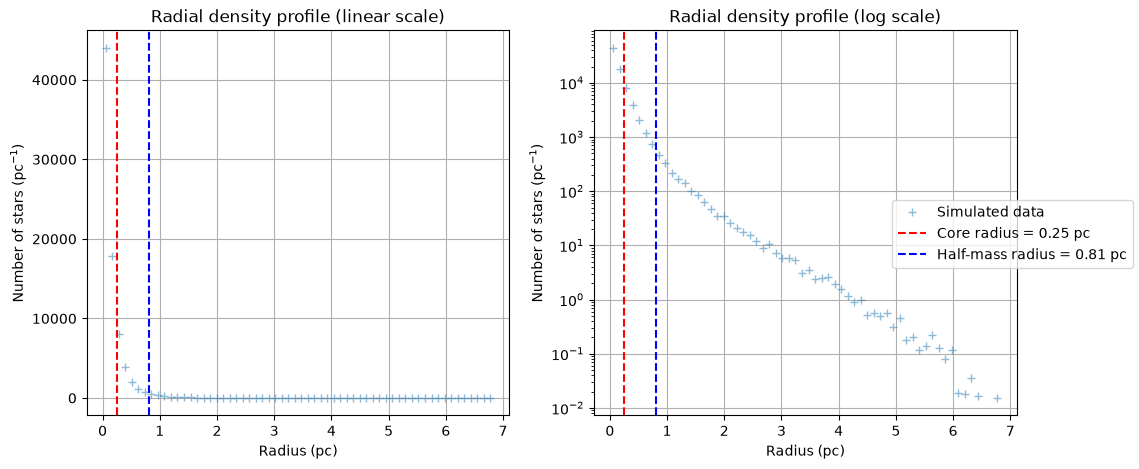

In [44]:
from amuse.units import units, constants, nbody_system
from amuse.lab import Particles, Particle
from amuse.io import read_set_from_file
import numpy as np
import matplotlib.pyplot as plt

particles = read_set_from_file('star_cluster_001.amuse', format='amuse')

particles.move_to_center()
x = particles.position.x.value_in(units.parsec)
y = particles.position.y.value_in(units.parsec)
z = particles.position.z.value_in(units.parsec)
r = np.sqrt(x**2 + y**2 + z**2)

counts, edges = np.histogram(r, bins=60, range=(0, r.max()))

r_center = (edges[:-1] + edges[1:]) / 2
shell_volume = 4 * np.pi * r_center**2 * np.diff(edges)
n_r = counts / shell_volume                     # stars / pc^3

def get_half_mass_radius(particles=particles, r=r):
    """Calculate the half-mass radius of a star cluster.
    Loop through the stars in order of increasing distance from the center, adding their mass until we reach half the total mass.
    Return the distance of the last star added.
    """
    
    #order the particles by distance from the center
    order = np.argsort(r)
    sorted_r = r[order]
    sorted_particles = particles[order]
    
    #initialize the mass to zero
    total_mass = particles.mass.sum()
    mass = 0.0 | units.kg
    # loop through the sorted stars and add their mass until we reach half the total mass
    for i in range(len(sorted_particles)):
        mass += sorted_particles[i].mass
        if mass >= total_mass / 2:
            return sorted_r[i]
    return None

# unit converter built from the total mass and the virial radius.
converter = nbody_system.nbody_to_si(particles.mass.sum(), particles.virial_radius())
# Core radius + core density (Casertano & Hut 1985, via the Hop code).
pos, rcore, rhocore = particles.densitycentre_coreradius_coredens(unit_converter=converter)
core_radius = converter.to_si(rcore).value_in(units.parsec)

half_mass_radius = get_half_mass_radius(particles=particles, r=r)
print(f'half-mass radius (from function) = {half_mass_radius:.3f} pc')


fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(r_center, n_r, '+', alpha=0.5, label='Simulated data')
ax[0].set_xlabel('Radius (pc)')
ax[0].set_ylabel('Number of stars (pc$^{-1}$)')

ax[0].axvline(core_radius, color='red', linestyle='--', label=f'Core radius = {core_radius:.2f} pc')
ax[0].axvline(half_mass_radius, color='blue', linestyle='--', label=f'Half-mass radius = {half_mass_radius:.2f} pc')
ax[0].grid()
ax[0].set_title('Radial density profile (linear scale)')

ax[1].plot(r_center, n_r, '+', alpha=0.5)
ax[1].set_xlabel('Radius (pc)')
ax[1].set_ylabel('Number of stars (pc$^{-1}$)')
ax[1].set_yscale('log')

ax[1].axvline(core_radius, color='red', linestyle='--')
ax[1].axvline(half_mass_radius, color='blue', linestyle='--')
ax[1].grid()
ax[1].set_title('Radial density profile (log scale)')

fig.legend(loc='right')
plt.show()


<div class = 'alert alert-info'>

### Plot in Log space in the y axis

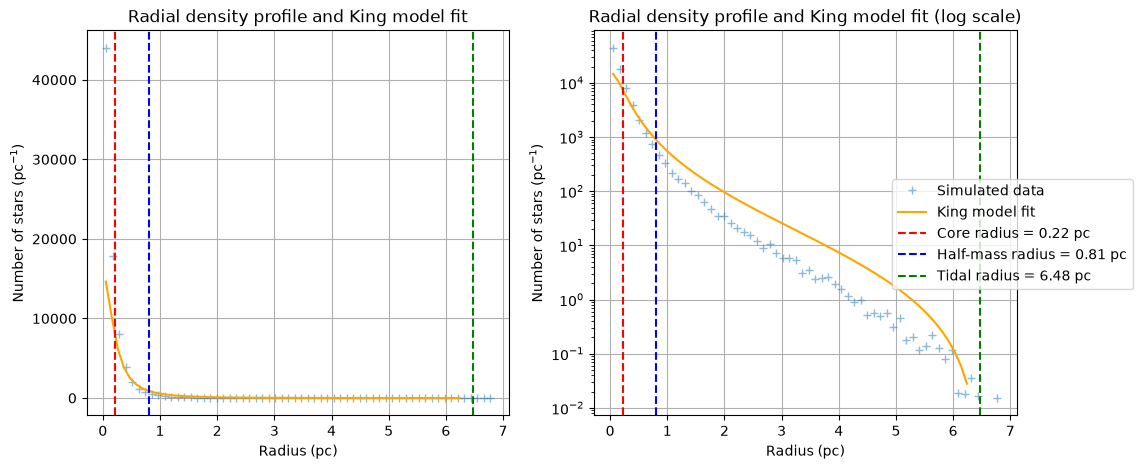

In [45]:
import scipy.optimize as opt

R = np.sqrt(x**2 + y**2)                         # project onto one plane
c2, e2 = np.histogram(R, bins=60, range=(0, R.max()))
R_center = (e2[:-1] + e2[1:]) / 2
annulus_area = np.pi * (e2[1:]**2 - e2[:-1]**2)
Sigma = c2 / annulus_area                        # stars / pc^2

def king_surface(R, S0, rc, rt):
    return S0 * (1/np.sqrt(1 + (R/rc)**2) - 1/np.sqrt(1 + (rt/rc)**2))**2

popt, _ = opt.curve_fit(king_surface, R_center, Sigma,
                        p0=[Sigma.max(), core_radius, R.max()], maxfev=20000)
S0, rc, rt = popt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(r_center, n_r, '+', alpha=0.5, label='Simulated data')
ax[0].plot(R_center, king_surface(R_center, S0, rc, rt), '-', color='orange', label='King model fit')
ax[0].set_xlabel('Radius (pc)')
ax[0].set_ylabel('Number of stars (pc$^{-1}$)')

ax[0].axvline(rc, color='red', linestyle='--', label=f'Core radius = {rc:.2f} pc')
ax[0].axvline(half_mass_radius, color='blue', linestyle='--', label=f'Half-mass radius = {half_mass_radius:.2f} pc')
ax[0].axvline(rt, color='green', linestyle='--', label=f'Tidal radius = {rt:.2f} pc')
ax[0].grid()
ax[0].set_title('Radial density profile and King model fit')

ax[1].plot(r_center, n_r, '+', alpha=0.5)
ax[1].plot(R_center, king_surface(R_center, S0, rc, rt), '-', color='orange')
ax[1].set_xlabel('Radius (pc)')
ax[1].set_ylabel('Number of stars (pc$^{-1}$)')
ax[1].set_yscale('log')

ax[1].axvline(rc, color='red', linestyle='--')
ax[1].axvline(half_mass_radius, color='blue', linestyle='--')
ax[1].axvline(rt, color='green', linestyle='--')
ax[1].grid()
ax[1].set_title('Radial density profile and King model fit (log scale)')

fig.legend(loc='right')
plt.show()
